In [ ]:
# ============================================================================
# Akita Model Evaluation
# ============================================================================
# This notebook evaluates a trained Akita model on the test set by:
# 1. Loading a trained model checkpoint
# 2. Running inference on test data
# 3. Computing evaluation metrics (Pearson, Spearman, MSE)
# 4. Visualizing predictions vs ground truth
# ============================================================================

In [1]:
# %% Imports
import os
import sys

import numpy as np
import torch
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import mean_squared_error
from torch.utils.data import DataLoader

In [2]:
# Add parent directory (pytorch_akita) to path
parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

In [3]:
from akita_model.model import SeqNN
from data_preprocessing.dataset import HiCDataset
from utils import plot_contact_map, upper_triu_to_matrix

### Configuration

In [4]:
# Model selection
MODEL_IDX = 0  # Which fold/model to evaluate

# Paths
# Fine-tuned model
MODEL_PATH = (
    f"/home1/smaruj/pytorch_akita/models/finetuned/mouse/Hsieh2019_mESC/checkpoints/"
    f"Akita_v2_mouse_Hsieh2019_mESC_model{MODEL_IDX}_finetuned.pth"
)
# pre-trained model
# MODEL_PATH = (
#     f"/home1/smaruj/pytorch_akita/models/pretrained/mouse/Hsieh2019_mESC/"
#     f"Akita_v2_mouse_Hsieh2019_mESC_model{MODEL_IDX}.pth"
# )

DATA_DIR = "/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/Akita_pytorch_training_data/mouse_training_data/Hsieh2019_mESC"

# Evaluation parameters
BATCH_SIZE = 2
NUM_WORKERS = 4
NUM_EXAMPLES_TO_PLOT = 3  # Number of examples to visualize
MATRIX_SIZE = 512  # Size of Hi-C contact matrix
DIAGONAL_OFFSET = 2  # Number of diagonals to skip

In [5]:
# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# %% Load Model
print("=" * 70)
print("Loading model...")
print("=" * 70)
print(f"Model path: {MODEL_PATH}")

# Load model
model = SeqNN()
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.to(device)
model.eval()

print("✓ Model loaded successfully")
print("✓ Model set to evaluation mode")
print()

Using device: cuda
Loading model...
Model path: /home1/smaruj/pytorch_akita/models/finetuned/mouse/Hsieh2019_mESC/checkpoints/Akita_v2_mouse_Hsieh2019_mESC_model0_finetuned.pth
✓ Model loaded successfully
✓ Model set to evaluation mode



### Load Test Data

In [6]:
# Get test fold files
test_fold = f"fold{MODEL_IDX}"
all_files = [os.path.join(DATA_DIR, f) for f in os.listdir(DATA_DIR) if f.endswith(".pt")]
test_files = [f for f in all_files if test_fold in f]

print(f"Test fold: {test_fold}")
print(f"Found {len(test_files)} test files")

Test fold: fold0
Found 8 test files


In [7]:
# Create test dataset and dataloader
test_dataset = HiCDataset(test_files)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True
)

print(f"✓ Test dataset created: {len(test_dataset)} samples")
print(f"✓ Dataloader created: {len(test_loader)} batches")
print()

Loading file: /project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/Akita_pytorch_training_data/mouse_training_data/Hsieh2019_mESC/fold0_0.pt
Loading file: /project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/Akita_pytorch_training_data/mouse_training_data/Hsieh2019_mESC/fold0_1.pt
Loading file: /project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/Akita_pytorch_training_data/mouse_training_data/Hsieh2019_mESC/fold0_2.pt
Loading file: /project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/Akita_pytorch_training_data/mouse_training_data/Hsieh2019_mESC/fold0_3.pt
Loading file: /project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/Akita_pytorch_training_data/mouse_training_data/Hsieh2019_mESC/fold0_4.pt
Loading file: /project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/Akita_pytorch_training_data/mouse_training_data/Hsieh2019_mESC/fold0_5.pt
Loading file: /project2/fudenber_735/smaruj/sequence

### Run Inference

In [8]:
scd_values = []
all_preds = []
all_targets = []

with torch.no_grad():
    for batch_idx, (ohe_sequence, hic_vector) in enumerate(test_loader):
        # Move to device
        ohe_sequence = ohe_sequence.to(device)
        hic_vector = hic_vector.to(device)

        # Forward pass
        outputs = model(ohe_sequence)

        # Store predictions and targets
        all_preds.append(outputs.cpu())
        all_targets.append(hic_vector.cpu())

        # Compute SCD (Structural Consistency Distance)
        # SCD = sqrt(sum of squared predicted contacts)
        scd_batch = torch.sqrt((outputs**2).sum(dim=(1, 2)))
        scd_values.extend(scd_batch.cpu().numpy())

        # Progress update
        if (batch_idx + 1) % 10 == 0:
            print(f"Processed {batch_idx + 1}/{len(test_loader)} batches")

# Concatenate all batches
all_preds = torch.cat(all_preds, dim=0)
all_targets = torch.cat(all_targets, dim=0)

print("✓ Inference complete")
print(f"  Total samples: {len(all_preds)}")
print(f"  Predictions shape: {all_preds.shape}")
print(f"  Targets shape: {all_targets.shape}")
print()

/home1/smaruj/miniconda3/envs/pytorch_hic/lib/python3.10/site-packages/torch/nn/modules/conv.py:306: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:84.)
  return F.conv1d(input, weight, bias, self.stride,


Processed 10/363 batches
Processed 20/363 batches
Processed 30/363 batches
Processed 40/363 batches
Processed 50/363 batches
Processed 60/363 batches
Processed 70/363 batches
Processed 80/363 batches
Processed 90/363 batches
Processed 100/363 batches
Processed 110/363 batches
Processed 120/363 batches
Processed 130/363 batches
Processed 140/363 batches
Processed 150/363 batches
Processed 160/363 batches
Processed 170/363 batches
Processed 180/363 batches
Processed 190/363 batches
Processed 200/363 batches
Processed 210/363 batches
Processed 220/363 batches
Processed 230/363 batches
Processed 240/363 batches
Processed 250/363 batches
Processed 260/363 batches
Processed 270/363 batches
Processed 280/363 batches
Processed 290/363 batches
Processed 300/363 batches
Processed 310/363 batches
Processed 320/363 batches
Processed 330/363 batches
Processed 340/363 batches
Processed 350/363 batches
Processed 360/363 batches
✓ Inference complete
  Total samples: 725
  Predictions shape: torch.Size

### Compute Metrics

In [9]:
# Flatten predictions and targets for metrics
preds_flat = all_preds.flatten().numpy()
targets_flat = all_targets.flatten().numpy()

# Create mask to remove NaNs in either array
mask = (~np.isnan(preds_flat)) & (~np.isnan(targets_flat))

preds_clean = preds_flat[mask]
targets_clean = targets_flat[mask]

print(f"Removed {len(preds_flat) - len(preds_clean)} NaN entries")

# Pearson correlation
pearson_corr, pearson_pval = pearsonr(targets_clean, preds_clean)
print(f"Pearson correlation:  {pearson_corr:.4f} (p-value: {pearson_pval:.2e})")

# Spearman correlation
spearman_corr, spearman_pval = spearmanr(targets_clean, preds_clean)
print(f"Spearman correlation: {spearman_corr:.4f} (p-value: {spearman_pval:.2e})")

# Mean Squared Error
mse = mean_squared_error(targets_clean, preds_clean)
print(f"MSE:                  {mse:.5f}")

# Mean Absolute Error
mae = np.mean(np.abs(targets_clean - preds_clean))
print(f"MAE:                  {mae:.5f}")

# SCD statistics
scd_mean = np.mean(scd_values)
scd_std = np.std(scd_values)
print("\nSCD statistics:")
print(f"  Mean: {scd_mean:.4f}")
print(f"  Std:  {scd_std:.4f}")
print()

Removed 4483705 NaN entries
Pearson correlation:  0.6590 (p-value: 0.00e+00)
Spearman correlation: 0.6090 (p-value: 0.00e+00)
MSE:                  0.11085
MAE:                  0.25195

SCD statistics:
  Mean: 112.1794
  Std:  43.0253



### Visualize Predictions


Example 1/3
----------------------------------------
Ground Truth:
Prediction (Pearson: 0.6430):

Example 2/3
----------------------------------------
Ground Truth:
Prediction (Pearson: 0.6289):

Example 3/3
----------------------------------------
Ground Truth:
Prediction (Pearson: 0.4963):


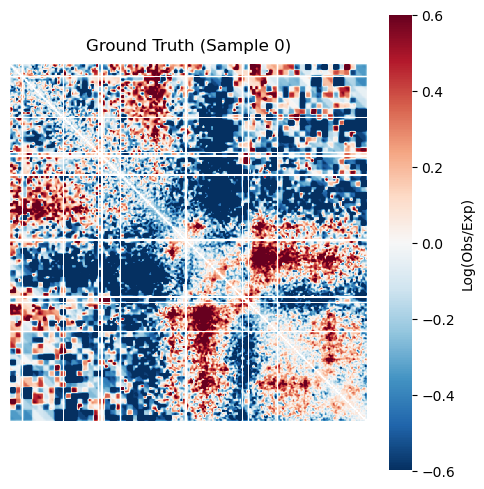

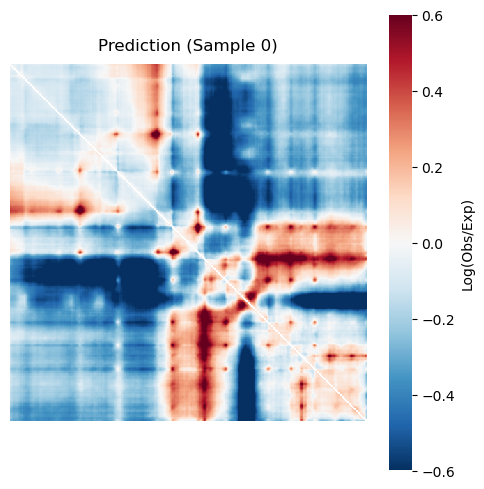

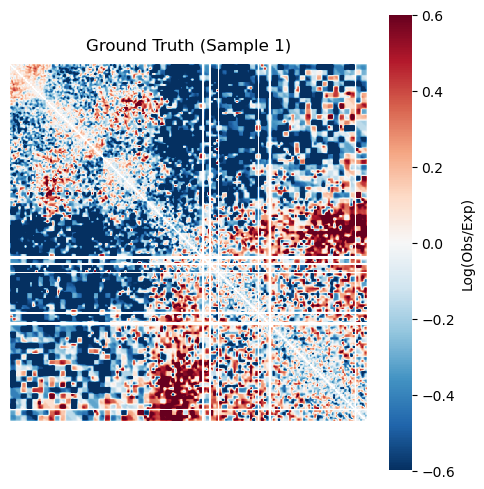

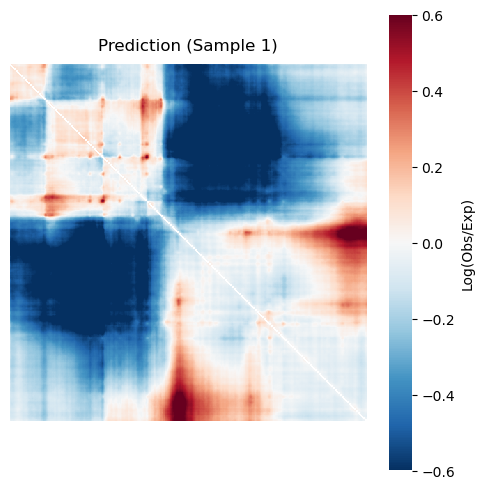

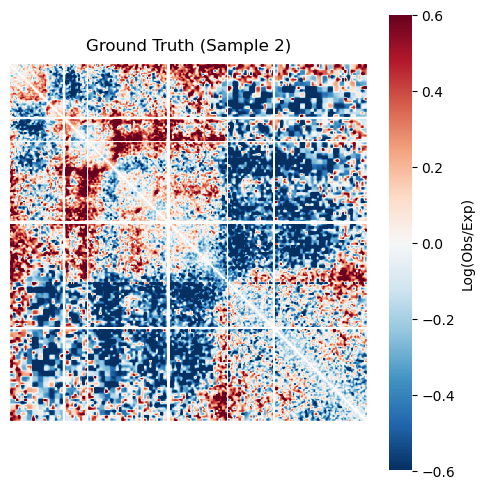

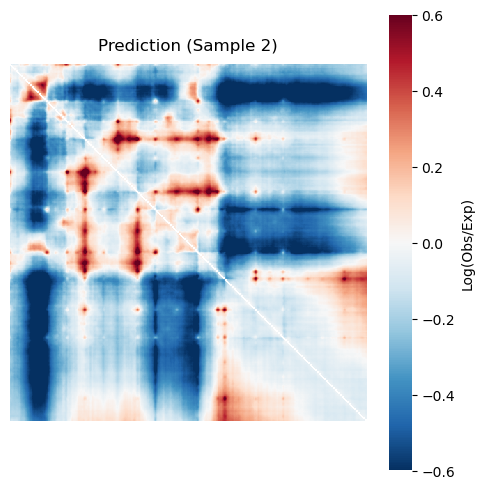

In [10]:
for i in range(min(NUM_EXAMPLES_TO_PLOT, len(all_preds))):
    print(f"\nExample {i + 1}/{NUM_EXAMPLES_TO_PLOT}")
    print("-" * 40)

    # Convert to matrices
    target_matrix = upper_triu_to_matrix(
        all_targets[i], matrix_len=MATRIX_SIZE, num_diags=DIAGONAL_OFFSET
    )
    pred_matrix = upper_triu_to_matrix(
        all_preds[i], matrix_len=MATRIX_SIZE, num_diags=DIAGONAL_OFFSET
    )

    # Create mask to remove NaNs in either array
    mask = (~np.isnan(target_matrix)) & (~np.isnan(pred_matrix))

    preds_clean = pred_matrix[mask]
    targets_clean = target_matrix[mask]
    
    # Compute per-sample correlation
    sample_corr = pearsonr(preds_clean, targets_clean)[0]

    # Plot target
    print("Ground Truth:")
    plot_contact_map(target_matrix, title=f"Ground Truth (Sample {i})")

    # Plot prediction
    print(f"Prediction (Pearson: {sample_corr:.4f}):")
    plot_contact_map(pred_matrix, title=f"Prediction (Sample {i})")